## Ссылка на репозиторий проекта
https://github.com/HelenZotw/yandex_project

**Описание проекта**

Бизнес-задача. Интернет-магазин «В один клик» заметил снижение активности постоянных покупателей. Привлечение новых клиентов становится менее эффективно, поэтому компания хочет сосредоточиться на удержании за счёт персонализированных предложений.

Цель исследования. Построить модель, которая предскажет вероятность снижения активности клиента в ближайшие 3 месяца, и на основе результатов сегментировать покупателей для разработки целевых маркетинговых кампаний.

Данные.

- market_file.csv — коммуникации, продуктовое и покупательское поведение, активность на сайте (целевой признак).

- market_money.csv — выручка по месяцам.

- market_time.csv — время на сайте.

- money.csv — прибыль клиента (для сегментации, не для обучения).

Подход и шаги решения.

- Загрузка и проверка схемы (учёт sep=";", decimal=",").

- Предобработка: приведение типов, нормализация «Период», обработка пропусков (импьютер в пайплайне), удаление константных/сверх-пропущенных фич.

- EDA: распределения ключевых признаков и сравнение по классам.

- Объединение таблиц: «разворот» периодов в отдельные колонки по выручке/времени.

- Корреляционный анализ и устранение мультиколлинеарности.

- Моделирование через Pipeline + ColumnTransformer:

    - два препроцессинга (OneHot+StandardScaler и Ordinal+MinMax),

    - модели: KNN, DecisionTree, LogisticRegression, SVC,

    - подбор гиперпараметров GridSearchCV по ROC-AUC.

- Интерпретация: Permutation Importance и SHAP для лучшей модели.

- Сегментация: объединяем proba(снижение) с прибылью и выделяем целевые группы (напр., «высокий риск × высокая прибыль»); формируем персональные предложения.

- Итог: выбор лучшей модели, ключевые драйверы, план коммуникаций и метрики A/B-теста (CR, ARPPU/выручка на пользователя, удержание D30).

In [1]:
!pip install -q shap
!pip install -U scikit-learn
!pip install -q phik

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.inspection import permutation_importance

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
# Проверка на адекватность: сравнение с константной моделью
from sklearn.dummy import DummyClassifier

import phik
from phik import phik_matrix

import shap

In [3]:
RANDOM_STATE = 42
sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110})

In [4]:
#Функции загрузки/проверок/нормализации
def load_csv_smart(path: str, must_have=None, sep=';', decimal=','):
    """Считывает CSV; если файл схлопнулся в одну колонку — пробует другие sep/decimal."""
    df = pd.read_csv(path, sep=sep, decimal=decimal, encoding="utf-8-sig")
    if df.shape[1] > 1:
        return df
    tried = []
    for s in [",",";","\t","|"]:
        for d in [",","."]:
            try:
                tmp = pd.read_csv(path, sep=s, decimal=d, encoding="utf-8-sig")
                if (must_have is None) or all(c in tmp.columns for c in must_have):
                    return tmp
                tried.append((s,d,list(tmp.columns)))
            except Exception:
                tried.append((s,d,"<read_error>"))
    try:
        tmp = pd.read_csv(path, sep=None, engine="python")
        return tmp
    except Exception:
        raise ValueError(f"Не удалось корректно прочитать {path}. Пробовали: {tried}")

def check_schema(df: pd.DataFrame, expected_cols: list, name: str) -> pd.DataFrame:
    missing = [c for c in expected_cols if c not in df.columns]
    extra = [c for c in df.columns if c not in expected_cols]
    return pd.DataFrame({
        "dataset":[name], "ok":[len(missing)==0],
        "missing":[", ".join(missing)], "extra":[", ".join(extra)],
        "rows":[len(df)], "cols":[df.shape[1]]
    })

def normalize_periods(s: pd.Series) -> pd.Series:
    mapping = {
        "предыдущий_месяц": "предыдущий_месяц",
        "препредыдущий_месяц": "препредыдущий_месяц",
        "текущий_месяц": "текущий_месяц",
        "прошлый_год": "прошлый_год",
        "предыдцщий_месяц": "предыдущий_месяц",
    }
    s_ = s.astype("string").str.strip().str.lower()
    return s_.map(mapping).fillna(s_)

#Быстрый предпросмотр датасета
def preview(df, name):
    print(f'--- {name} ---')
    print(f'Размер: {df.shape[0]} x {df.shape[1]}')
    display(df.head())
    print('\nПропуски по столбцам:')
    print(df.isna().sum())
    print('Дубликаты:', df.duplicated().sum())
    print('-'*40, '\n')

def report_missing(df: pd.DataFrame, top=20):
    miss_cnt = df.isna().sum()
    miss_pct = df.isna().mean()
    out = (
        pd.DataFrame({"na_count": miss_cnt, "na_share": miss_pct})
        .sort_values("na_share", ascending=False)
        .head(top)
    )
    display(out.style.format({"na_share": "{:.1%}"}))
    return out

def money_time_wide(market_money: pd.DataFrame, market_time: pd.DataFrame):
    m = market_money.copy()
    t = market_time.copy()
    m["Период"] = normalize_periods(m["Период"])
    t["Период"] = normalize_periods(t["Период"])
    mw = m.pivot_table(index="id", columns="Период", values="Выручка", aggfunc="sum").rename(columns={
        "препредыдущий_месяц":"Выручка_препредыдущий",
        "предыдущий_месяц":"Выручка_предыдущий",
        "текущий_месяц":"Выручка_текущий",
    })
    tw = t.pivot_table(index="id", columns="Период", values="минут", aggfunc="sum").rename(columns={
        "препредыдущий_месяц":"Время_препредыдущий",
        "предыдущий_месяц":"Время_предыдущий",
        "текущий_месяц":"Время_текущий",
        "прошлый_год":"Время_прошлый_год",
    })
    for c in ["Выручка_препредыдущий","Выручка_предыдущий","Выручка_текущий"]:
        if c not in mw.columns: mw[c] = np.nan
    for c in ["Время_препредыдущий","Время_предыдущий","Время_текущий","Время_прошлый_год"]:
        if c not in tw.columns: tw[c] = np.nan
    
        const_cols_tw = []
    for col in tw.columns:
        if tw[col].nunique(dropna=True) <= 1:
            const_cols_tw.append(col)
    
    if const_cols_tw:
        print(f"Удаляем константные столбцы из таблицы времени: {const_cols_tw}")
        tw = tw.drop(columns=const_cols_tw)
        
    return mw, tw

def build_preprocessors(num_features, nominal_features, ordinal_features):
    transformers = [
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")), 
            ("sc", StandardScaler())
        ]), num_features),
        ("cat_nominal", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")), 
            ("oh", OneHotEncoder(drop='first', handle_unknown="ignore"))
        ]), nominal_features),
    ]
    
    # Добавляем ординальные, если они есть
    if len(ordinal_features) > 0:
        transformers.append(
            ("cat_ordinal", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")), 
                ("ord", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
            ]), ordinal_features)
        )
    
    preprocessor = ColumnTransformer(transformers)
    return preprocessor

In [5]:
def train_all_models_updated(X_train, y_train, cv, scoring, num_features, nominal_features, ordinal_features):
    """Обучает модели с перебором скейлеров через сетку параметров"""
    results = []
    
    # Определяем модели и их параметры
    models = [
        ("KNN", KNeighborsClassifier(), {
            "clf__n_neighbors": [5, 11, 21], 
            "clf__weights": ["uniform", "distance"],
            "pre__num__sc": [StandardScaler(), MinMaxScaler()]
        }),
        ("DecisionTree", DecisionTreeClassifier(random_state=RANDOM_STATE), {
            "clf__max_depth": [5, 10, 15, None], 
            "clf__min_samples_leaf": [1, 3, 5, 10],
            "pre__num__sc": [StandardScaler(), MinMaxScaler()]
        }),
        ("LogisticRegression", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), {
            "clf__C": [0.5, 1, 3, 10],
            "pre__num__sc": [StandardScaler(), MinMaxScaler()]
        }),
        ("SVC", SVC(probability=True, random_state=RANDOM_STATE), {
            "clf__C": [0.5, 1, 3, 10], 
            "clf__gamma": ["scale", "auto"],
            "pre__num__sc": [StandardScaler(), MinMaxScaler()]
        }),
        ("GradientBoosting", GradientBoostingClassifier(random_state=RANDOM_STATE), {
            "clf__n_estimators": [50, 100, 150],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__max_depth": [3, 5],
            "pre__num__sc": [StandardScaler(), MinMaxScaler()]
        }),
    ]
        
    # Для каждой модели создаём ОДИН препроцессор (без скейлера внутри, скейлер будет из сетки)
    for name, est, grid in models:
        # Создаём препроцессор, где скейлер будет подставляться из grid
        prep = build_preprocessors(num_features, nominal_features, ordinal_features)
        pipe = Pipeline([("pre", prep), ("clf", est)])
        gs = GridSearchCV(pipe, grid, scoring=scoring, cv=cv, refit=True, verbose=0)
        gs.fit(X_train, y_train)
        results.append((name, gs))
    
    return results

def build_preprocessors(num_features, nominal_features, ordinal_features):
    transformers = [
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")), 
            ("sc", StandardScaler())  # Скейлер по умолчанию, но будет заменён через grid
        ]), num_features),
        ("cat_nominal", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")), 
            ("oh", OneHotEncoder(drop='first', handle_unknown="ignore"))
        ]), nominal_features),
    ]
    
    if len(ordinal_features) > 0:
        transformers.append(
            ("cat_ordinal", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")), 
                ("ord", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
            ]), ordinal_features)
        )
    
    preprocessor = ColumnTransformer(transformers)
    return preprocessor

In [6]:
def evaluate_best(results, X_test, y_test):
    """Выбирает лучшую модель по CV и оценивает только её на test"""
    # Сравниваем модели по CV score
    table = []
    for name, gs in results:
        table.append({
            "model": name,
            "cv_best": gs.best_score_,
            "best_params": gs.best_params_,
            "best_est": gs.best_estimator_,
        })
    
    # Находим лучшую по CV
    best = max(table, key=lambda d: d["cv_best"])
    
    # Оцениваем ТОЛЬКО лучшую на test
    best_est = best["best_est"]
    if hasattr(best_est["clf"], "predict_proba"):
        proba = best_est.predict_proba(X_test)[:,1]
    else:
        dec = best_est.decision_function(X_test)
        proba = pd.Series(dec).rank(pct=True).values
    
    best["test_roc_auc"] = roc_auc_score(y_test, proba)
    best["test_pr_auc"] = average_precision_score(y_test, proba)
    
    # Создаём таблицу результатов (только CV scores для всех моделей)
    df = pd.DataFrame([{k:v for k,v in r.items() if k!='best_est'} for r in table]).sort_values("cv_best", ascending=False)
    
    # Добавляем test scores только для лучшей
    df["test_roc_auc"] = df["model"].apply(lambda x: best["test_roc_auc"] if x == best["model"] else None)
    df["test_pr_auc"] = df["model"].apply(lambda x: best["test_pr_auc"] if x == best["model"] else None)
    
    return df, best

In [7]:
def feature_importance_step(best_est, X_train, X_test, y_test, num_features, cat_features):
    """Анализ важности признаков: Permutation Importance + SHAP"""
    
    # 1. Permutation Importance
    pi = permutation_importance(best_est, X_test, y_test, scoring="roc_auc", 
                                n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
    imp_pi = (pd.DataFrame({"feature": list(X_test.columns), "importance": pi.importances_mean})
                .sort_values("importance", ascending=False))
    
    print("Top-15 признаков по Permutation Importance:")
    display(imp_pi.head(15))
    
    # 2. SHAP на исходных признаках
    try:
        X_test_sample = X_test.sample(min(50, len(X_test)), random_state=RANDOM_STATE)
        X_train_bg = X_train.sample(min(30, len(X_train)), random_state=RANDOM_STATE)
        
        def model_predict(X_original):
            X_df = pd.DataFrame(X_original, columns=X_test.columns)
            if hasattr(best_est, 'predict_proba'):
                return best_est.predict_proba(X_df)[:, 1]
            else:
                from scipy.special import expit
                return expit(best_est.decision_function(X_df))
        
        print("\n Расчет SHAP...")
        explainer = shap.KernelExplainer(model_predict, X_train_bg)
        shap_values = explainer.shap_values(X_test_sample, nsamples=50)
        
        print("\nSHAP Summary Plot:")
        shap.summary_plot(shap_values, X_test_sample, max_display=15, show=False)
        
        ax = plt.gca()
        ax.set_ylabel('Признаки', fontsize=12)
        ax.set_xlabel('Влияние на предсказание (SHAP value)', fontsize=11)
        ax.set_title('Важность признаков (SHAP)', fontsize=14, pad=20)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"\n SHAP недоступен: {e}")
    
    return imp_pi

## Загрузка данных

In [8]:
path_market_file  = '/Users/elenazotova/one-click/market_file.csv'
path_market_money = '/Users/elenazotova/one-click/market_money.csv'
path_market_time  = '/Users/elenazotova/one-click/market_time.csv'
path_money        = '/Users/elenazotova/one-click/money.csv'

In [9]:
market_file  = load_csv_smart(path_market_file,  must_have=['id','Покупательская активность'])
market_money = load_csv_smart(path_market_money, must_have=['id','Период','Выручка'])
market_time  = load_csv_smart(path_market_time,  must_have=['id','Период','минут'])
money        = load_csv_smart(path_money,        must_have=['id','Прибыль'])

In [10]:
preview(market_file, 'market_file')

--- market_file ---
Размер: 1300 x 13


,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.0,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2



Пропуски по столбцам:
id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64
Дубликаты: 0
---------------------------------------- 



Таблица market_file содержит 1300 строк и 13 столбцов, все признаки соответствуют описанию. Пропусков и дубликатов нет, данные выглядят корректными и готовы к дальнейшему анализу.

In [11]:
preview(market_money, 'market_money')

--- market_money ---
Размер: 3900 x 3


,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6



Пропуски по столбцам:
id         0
Период     0
Выручка    0
dtype: int64
Дубликаты: 0
---------------------------------------- 



Таблица market_money содержит 3900 строк и 3 столбца. Пропусков и дубликатов нет, периоды и выручка указаны корректно — данные чистые и готовы к объединению.

In [12]:
preview(market_time, 'market_time')

--- market_time ---
Размер: 2600 x 3


,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13



Пропуски по столбцам:
id        0
Период    0
минут     0
dtype: int64
Дубликаты: 0
---------------------------------------- 



Таблица market_time содержит 2600 строк и 3 столбца. Пропусков и дубликатов нет, периоды и минуты заполнены корректно — данные чистые и готовы к работе.

In [13]:
preview(money, 'money')

--- money ---
Размер: 1300 x 2


,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21



Пропуски по столбцам:
id         0
Прибыль    0
dtype: int64
Дубликаты: 0
---------------------------------------- 



Таблица money содержит 1300 строк и 2 столбца. Пропусков и дубликатов нет, прибыль указана корректно — данные чистые и пригодны для сегментации.

In [14]:
display(pd.concat([
    check_schema(market_file,  ['id','Покупательская активность','Тип сервиса','Разрешить сообщать','Маркет_актив_6_мес','Маркет_актив_тек_мес','Длительность','Акционные_покупки','Популярная_категория','Средний_просмотр_категорий_за_визит','Неоплаченные_продукты_штук_квартал','Ошибка_сервиса','Страниц_за_визит'], 'market_file'),
    check_schema(market_money, ['id','Период','Выручка'], 'market_money'),
    check_schema(market_time,  ['id','Период','минут'], 'market_time'),
    check_schema(money,        ['id','Прибыль'], 'money')
], ignore_index=True))

,dataset,ok,missing,extra,rows,cols
0,market_file,True,,,1300,13
1,market_money,True,,,3900,3
2,market_time,True,,,2600,3
3,money,True,,,1300,2


Все четыре таблицы прошли проверку схемы: нужные столбцы на месте, лишних нет, размеры корректны (ok = True). Данные загружены и соответствуют описанию.

**Вывод**

Все четыре источника данных успешно загружены и соответствуют описанию.
market_file (1300×13), market_money (3900×3), market_time (2600×3) и money (1300×2) не содержат пропусков и дубликатов; состав столбцов полностью совпадает с ожидаемым (ok = True по проверке схемы). Форматы периодов и числовые поля читаются корректно с учётом возможных sep=";" и decimal=",".

##  Предобработка данных

In [15]:
# Стрип заголовков
for df in [market_file, market_money, market_time, money]:
    df.columns = df.columns.str.strip()

# Типы
for df in [market_file, market_money, market_time, money]:
    if 'id' in df.columns: df['id'] = pd.to_numeric(df['id'], errors='coerce')

num_cols_file = ['Маркет_актив_6_мес','Маркет_актив_тек_мес','Длительность','Акционные_покупки',
                 'Средний_просмотр_категорий_за_визит','Неоплаченные_продукты_штук_квартал','Ошибка_сервиса','Страниц_за_визит']
for c in num_cols_file:
    if c in market_file.columns: market_file[c] = pd.to_numeric(market_file[c], errors='coerce')

market_money['Выручка'] = pd.to_numeric(market_money['Выручка'], errors='coerce')
market_time['минут']    = pd.to_numeric(market_time['минут'], errors='coerce')
money['Прибыль']        = pd.to_numeric(money['Прибыль'], errors='coerce')
money = money.drop_duplicates('id')

In [16]:
# Проверка и очистка категориальных признаков
print("=== Проверка категориальных признаков ===\n")

cat_cols = ['Тип сервиса', 'Разрешить сообщать', 'Популярная_категория', 'Покупательская активность']

for col in cat_cols:
    if col in market_file.columns:
        print(f"{col}:")
        print(market_file[col].value_counts())
             
        market_file[col] = market_file[col].astype(str).str.strip().str.lower()
        
        if col == 'Тип сервиса':
            market_file[col] = market_file[col].replace({
                'стандартт': 'стандарт'  # Исправление опечатки
            })
        
        print(f"\nПосле очистки:")
        print(market_file[col].value_counts())
        print("-" * 50 + "\n")
        
# === Проверка категориальных признаков ===

print("=== Проверка market_money ===")
if 'Период' in market_money.columns:
    print(market_money['Период'].value_counts())
    market_money['Период'] = normalize_periods(market_money['Период'])
    print("\nПосле нормализации:")
    print(market_money['Период'].value_counts())

print("\n=== Проверка market_time ===")
if 'Период' in market_time.columns:
    print(market_time['Период'].value_counts())
    market_time['Период'] = normalize_periods(market_time['Период'])
    print("\nПосле нормализации:")
    print(market_time['Период'].value_counts())

=== Проверка категориальных признаков ===

Тип сервиса:
стандарт     914
премиум      376
стандартт     10
Name: Тип сервиса, dtype: int64

После очистки:
стандарт    924
премиум     376
Name: Тип сервиса, dtype: int64
--------------------------------------------------

Разрешить сообщать:
да     962
нет    338
Name: Разрешить сообщать, dtype: int64

После очистки:
да     962
нет    338
Name: Разрешить сообщать, dtype: int64
--------------------------------------------------

Популярная_категория:
Товары для детей                        330
Домашний текстиль                       251
Косметика и аксесуары                   223
Техника для красоты и здоровья          184
Мелкая бытовая техника и электроника    174
Кухонная посуда                         138
Name: Популярная_категория, dtype: int64

После очистки:
товары для детей                        330
домашний текстиль                       251
косметика и аксесуары                   223
техника для красоты и здоровья          184


In [17]:
# Отчёт по пропускам
print("Пропуски: market_file"); report_missing(market_file)
print("Пропуски: market_money"); report_missing(market_money)
print("Пропуски: market_time"); report_missing(market_time)

Пропуски: market_file


,na_count,na_share
id,0,0.0%
Покупательская активность,0,0.0%
Тип сервиса,0,0.0%
Разрешить сообщать,0,0.0%
Маркет_актив_6_мес,0,0.0%
Маркет_актив_тек_мес,0,0.0%
Длительность,0,0.0%
Акционные_покупки,0,0.0%
Популярная_категория,0,0.0%
Средний_просмотр_категорий_за_визит,0,0.0%


Пропуски: market_money


,na_count,na_share
id,0,0.0%
Период,0,0.0%
Выручка,0,0.0%


Пропуски: market_time


,na_count,na_share
id,0,0.0%
Период,0,0.0%
минут,0,0.0%


,na_count,na_share
id,0,0.0
Период,0,0.0
минут,0,0.0


**Вывод**

- Приведены типы данных: числовые признаки преобразованы в numeric, ID в int
- Очищены категориальные признаки: удалены пробелы, приведены к нижнему регистру, исправлены опечатки ("стандартт" → "стандарт"), унифицированы значения "да/нет"
- Нормализованы названия периодов в таблицах с выручкой и временем
- Удалены дубликаты в таблице money

Пропуски отсутствуют (0% во всех таблицах). Данные готовы к объединению и моделированию. Кодирование категориальных признаков будет выполнено в пайплайне после split для предотвращения утечки данных.

## Исследовательский анализ данных

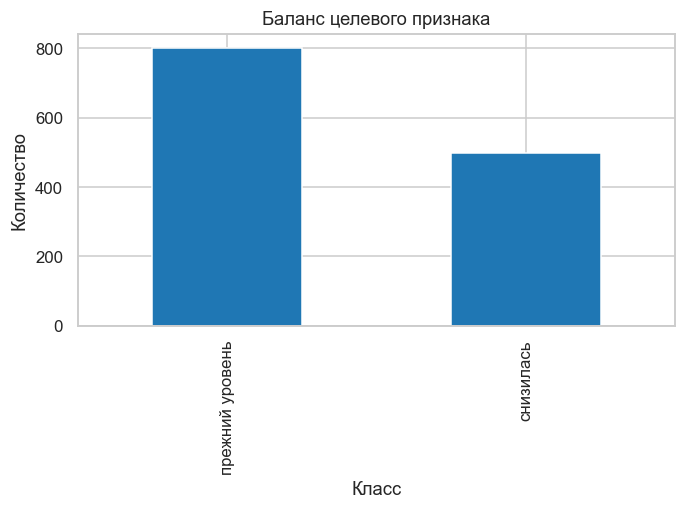

Активных 3 мес: 1297


In [18]:
if 'Покупательская активность' in market_file.columns:
    market_file['Покупательская активность'].value_counts().plot(kind='bar', title='Баланс целевого признака')
    plt.xlabel('Класс'); plt.ylabel('Количество'); plt.tight_layout(); plt.show()

mw_tmp = market_money.pivot_table(index='id', columns=normalize_periods(market_money['Период']), values='Выручка', aggfunc='sum')
for c in ['препредыдущий_месяц','предыдущий_месяц','текущий_месяц']:
    if c not in mw_tmp.columns: mw_tmp[c] = np.nan
active_ids = set(mw_tmp[(mw_tmp[['препредыдущий_месяц','предыдущий_месяц','текущий_месяц']].astype(float) > 0).all(axis=1)].index)
print("Активных 3 мес:", len(active_ids))

Баланс классов показывает: у большинства клиентов активность сохранилась на прежнем уровне, часть — снизилась. При этом 1297 клиентов были активны все 3 месяца подряд, что обеспечивает достаточный объём данных для анализа.

=== Анализ дискретных признаков ===


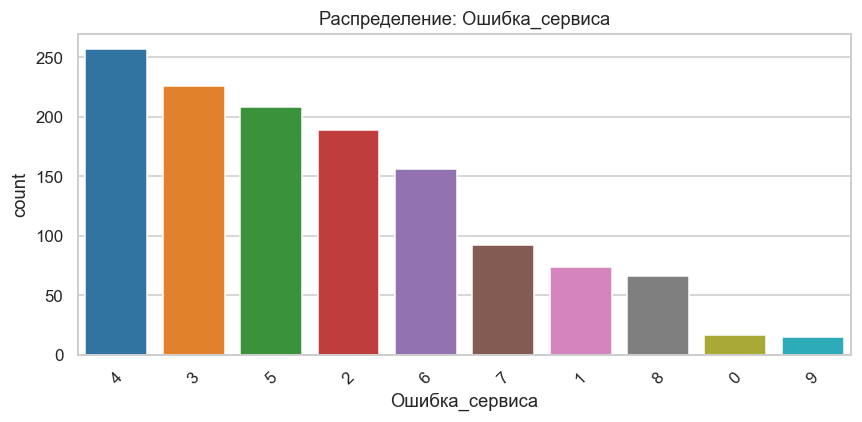

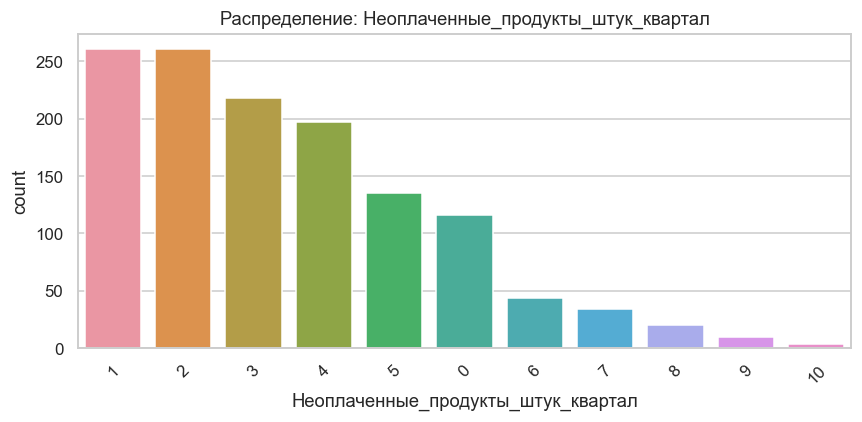

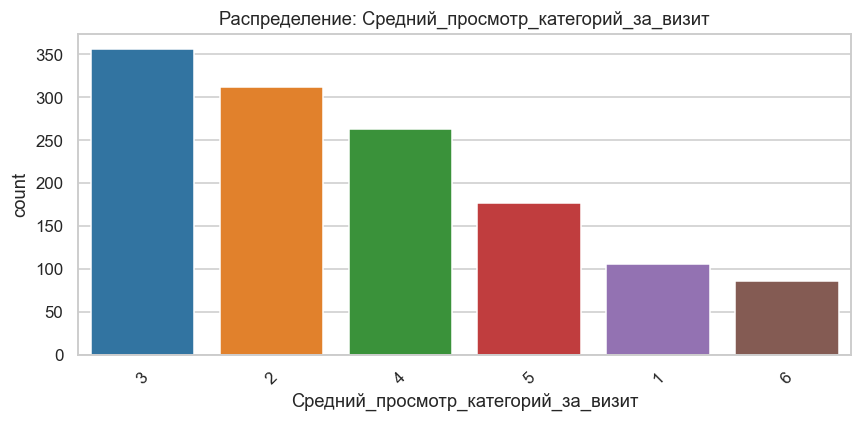

In [19]:
# Дискретные признаки - используем countplot
discrete_cols = ['Ошибка_сервиса', 'Неоплаченные_продукты_штук_квартал', 
                 'Средний_просмотр_категорий_за_визит']

print("=== Анализ дискретных признаков ===")
for col in discrete_cols:
    if col in market_file.columns and market_file[col].nunique() <= 20:
        plt.figure(figsize=(8,4))
        sns.countplot(data=market_file, x=col, order=market_file[col].value_counts().index)
        plt.title(f'Распределение: {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


- Ошибка_сервиса: большинство клиентов сталкиваются с 1-3 ошибками, есть небольшая группа с высоким числом сбоев (6-9)
- Неоплаченные_продукты_штук_квартал: преобладают клиенты с 1-2 неоплаченными товарами, распределение правостороннее с редкими случаями 8-10 товаров
- Средний_просмотр_категорий_за_визит: наиболее частые значения 1-3 категории за визит, что говорит о невысокой глубине взаимодействия с ассортиментом

Все три признака имеют целочисленные значения с ограниченным числом уникальных вариантов (до 20), что подтверждает их дискретную природу.

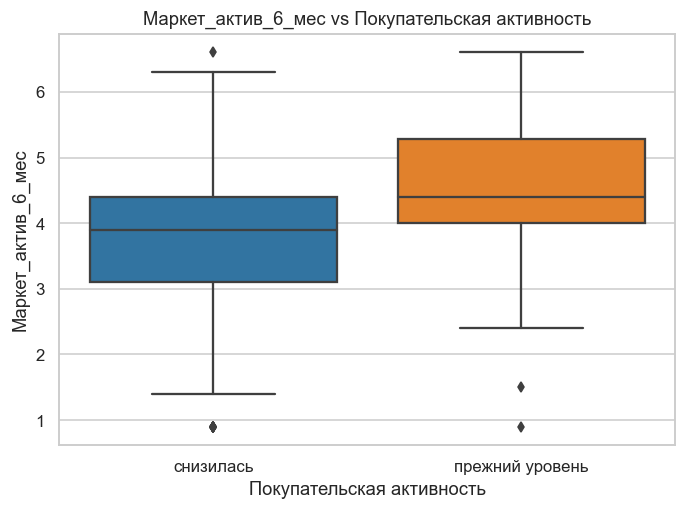

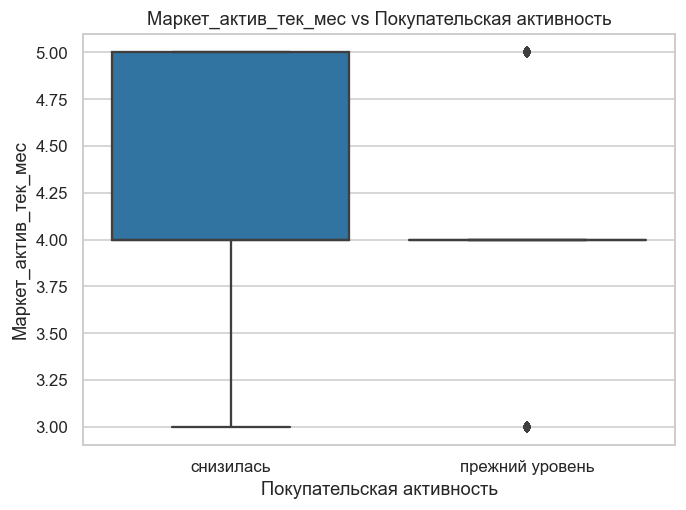

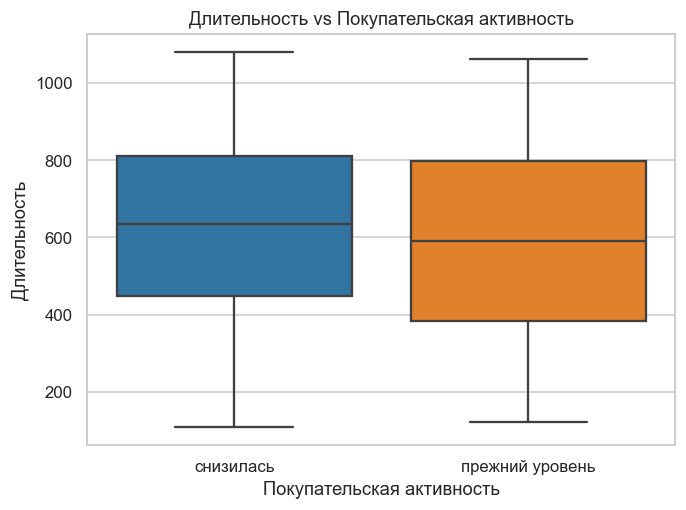

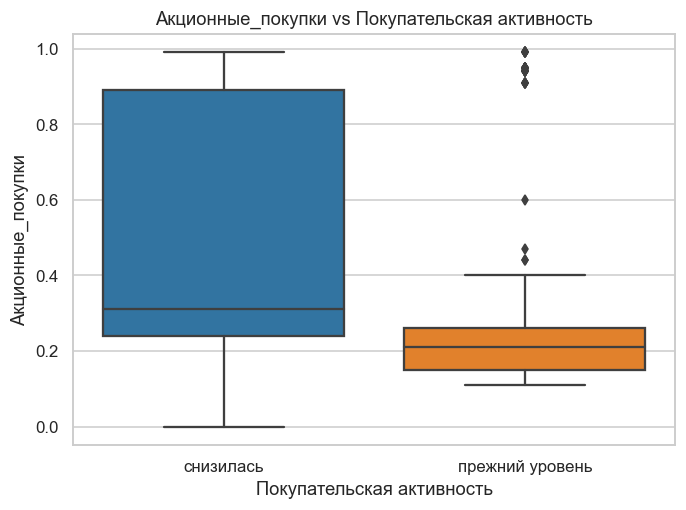

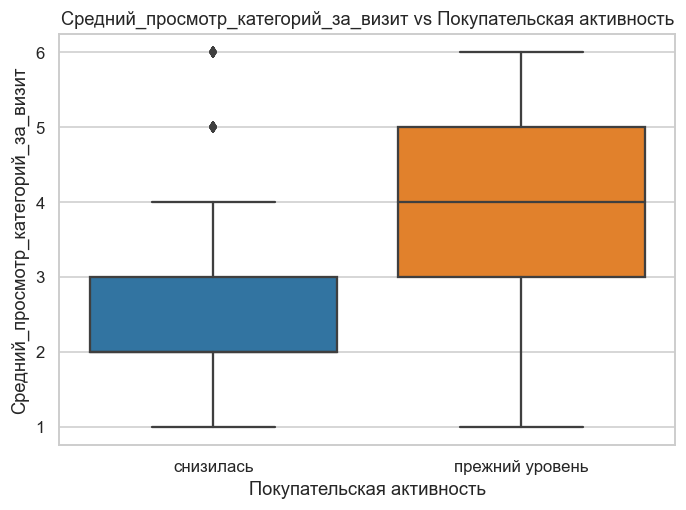

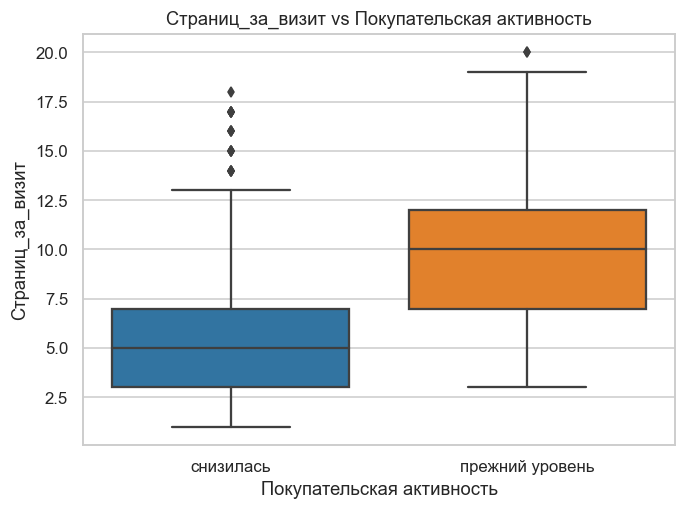

In [20]:
# Boxplot против целевой
if 'Покупательская активность' in market_file.columns:
    # Определяем признаки для boxplot
    eda_cols = ['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность', 
                'Акционные_покупки', 'Средний_просмотр_категорий_за_визит', 
                'Страниц_за_визит']
    
    for c in [x for x in eda_cols if x in market_file.columns]:
        try:
            sns.boxplot(data=market_file, x='Покупательская активность', y=c)
            plt.title(f'{c} vs Покупательская активность')
            plt.tight_layout()
            plt.show()
        except Exception:
            pass

- Маркет_актив — схожие значения в обеих группах.

- Длительность — почти одинаковое распределение.

- Акционные покупки — выше у группы со снижением.

- Просмотр категорий и страниц — больше у клиентов с прежним уровнем.

**Вывод**

Большинство клиентов сохраняют активность на прежнем уровне, однако заметна группа со снижением. При этом 1297 клиентов были активны все 3 месяца подряд, что создаёт основу для надёжного анализа.

По дополнительным признакам:

- Ошибка_сервиса чаще всего встречается 1–3 раза, но есть редкие клиенты с 6–9 сбоями.

- Неоплаченные товары обычно ограничиваются 1–2 штуками, редкие случаи достигают 8–10.

- Просмотр категорий за визит чаще всего равен 1–3, что указывает на ограниченную вовлечённость.

Сравнение групп показало:

- Маркетинговая активность и длительность регистрации почти не различаются.

- Акционные покупки выше у клиентов со снижением активности.

- Просмотр категорий и страниц выше у тех, кто сохранил активность.

Ключевым фактором удержания остаётся глубина взаимодействия с сайтом, тогда как маркетинговая активность и длительность регистрации не оказывают решающего влияния.

## Объединение таблиц

In [21]:
money_w, time_w = money_time_wide(market_money, market_time)

feat_money = money_w.copy()
feat_money['rev_diff_curr_prev'] = feat_money['Выручка_текущий'] - feat_money['Выручка_предыдущий']

feat_time = time_w.copy()
feat_time['time_diff_curr_prev'] = feat_time['Время_текущий'] - feat_time['Время_предыдущий']

merged_full = (market_file.set_index('id')
               .join(feat_money, how='left')
               .join(feat_time, how='left')
               .reset_index())

print("merged_full:", merged_full.shape)
const_cols = []
for col in merged_full.columns:
    if merged_full[col].nunique(dropna=True) <= 1:
        const_cols.append(col)

if const_cols:
    print(f"Удаляем константные столбцы: {const_cols}")
    merged_full = merged_full.drop(columns=const_cols)
    print(f"После удаления: {merged_full.shape}")

Удаляем константные столбцы из таблицы времени: ['Время_препредыдущий', 'Время_прошлый_год']
merged_full: (1300, 20)


Таблицы market_money и market_time были приведены к широкому формату (money_w, time_w).

- Добавлены новые признаки:

    - rev_diff_curr_prev — разница между выручкой текущего и предыдущего месяцев;

    - time_diff_curr_prev — разница во времени на сайте между текущим и предыдущим месяцем.

- Все таблицы объединены с market_file по ключу id, итоговый датафрейм содержит 1300 строк и 22 признака.

Вывод: удалось собрать единый датасет с полным набором признаков для последующего анализа и моделирования.

In [22]:
# Фильтруем: оставляем только активных клиентов
print("До фильтрации:", merged_full.shape)

active_mask = (
    (merged_full['Выручка_текущий'].fillna(0) > 0) & 
    (merged_full['Выручка_предыдущий'].fillna(0) > 0) &
    (merged_full['Выручка_препредыдущий'].fillna(0) > 0)
)

merged_full = merged_full[active_mask].copy()

print("После фильтрации (только активные клиенты):", merged_full.shape)
print(f"Удалено неактивных клиентов: {(~active_mask).sum()}")

До фильтрации: (1300, 20)
После фильтрации (только активные клиенты): (1297, 20)
Удалено неактивных клиентов: 3



=== Анализ выручки по периодам ===


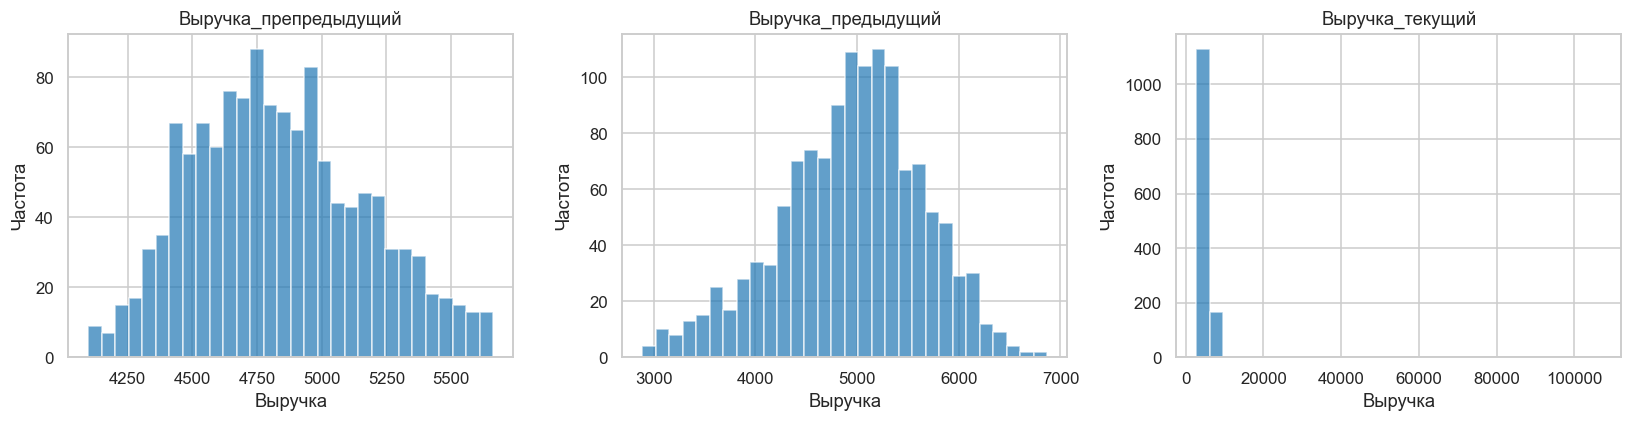


=== Анализ времени на сайте ===


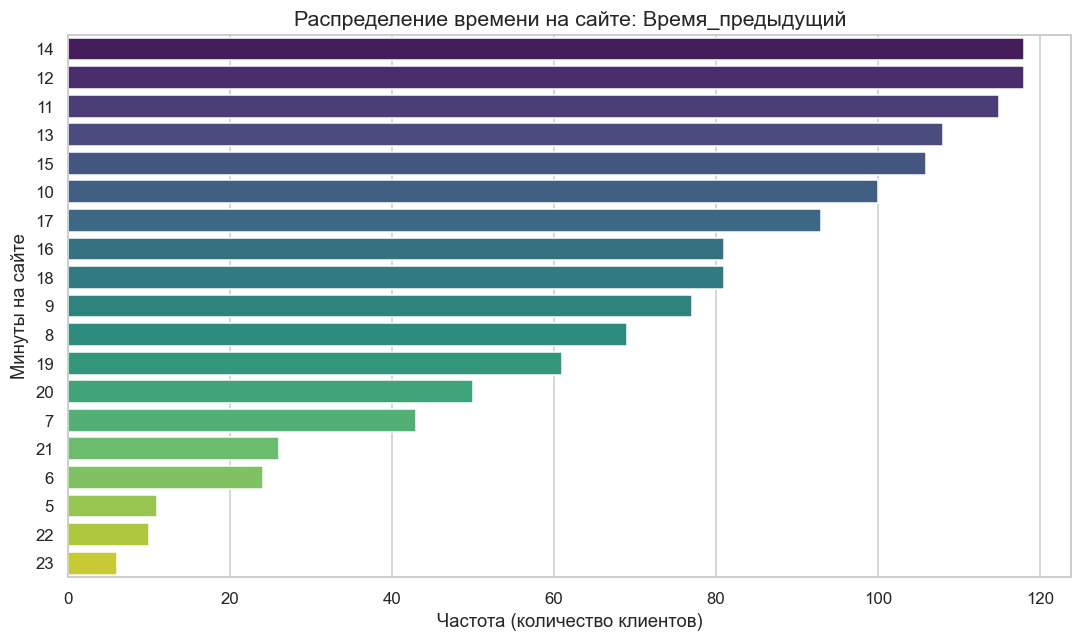

Уникальных значений в 'Время_предыдущий': 19
Топ-5 значений:
14    118
12    118
11    115
13    108
15    106
Name: Время_предыдущий, dtype: int64



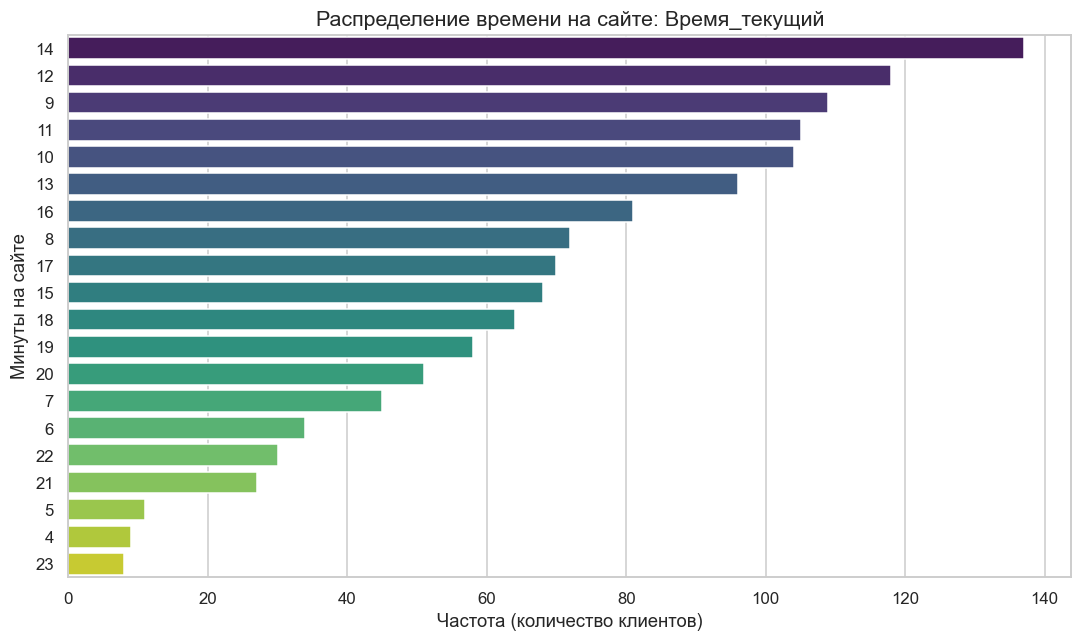

Уникальных значений в 'Время_текущий': 20
Топ-5 значений:
14    137
12    118
9     109
11    105
10    104
Name: Время_текущий, dtype: int64


=== Анализ прибыли ===


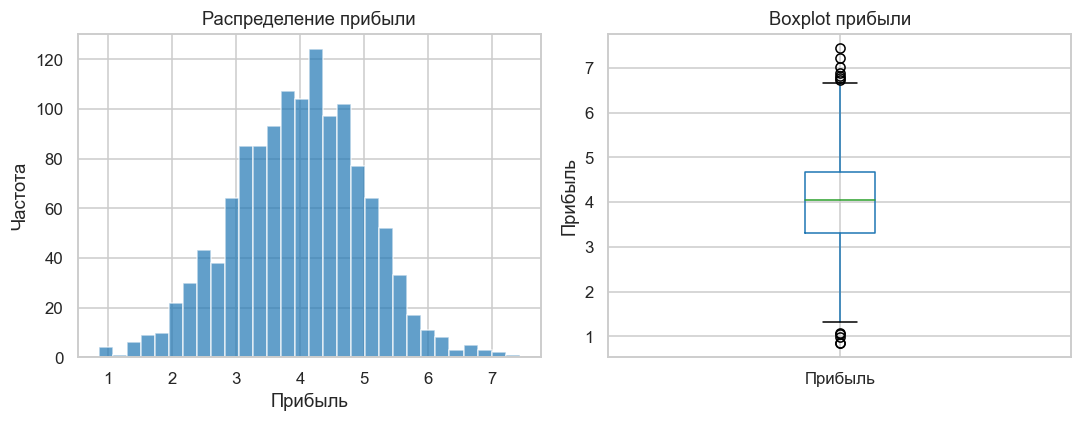


Статистика прибыли:
count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: Прибыль, dtype: float64


In [23]:
# Анализ выручки, прибыли и минут
print("\n=== Анализ выручки по периодам ===")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, period in enumerate(['Выручка_препредыдущий', 'Выручка_предыдущий', 'Выручка_текущий']):
    if period in merged_full.columns:
        merged_full[period].dropna().hist(bins=30, ax=axes[idx], alpha=0.7)
        axes[idx].set_title(period)
        axes[idx].set_xlabel('Выручка')
        axes[idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()

print("\n=== Анализ времени на сайте ===")
time_cols_available = [col for col in ['Время_препредыдущий', 'Время_предыдущий', 'Время_текущий', 'Время_прошлый_год'] 
                       if col in merged_full.columns]

if len(time_cols_available) > 0:
    
    for period in time_cols_available:
        unique_vals = merged_full[period].nunique(dropna=True)
        
        if unique_vals == 0:
            print(f"Столбец '{period}' пуст, пропускаем")
            continue
        
        plt.figure(figsize=(10, 6))
        

        top_values = merged_full[period].value_counts().head(30).index
        data_filtered = merged_full[merged_full[period].isin(top_values)]
        
        sns.countplot(
            data=data_filtered, 
            y=period, 
            order=top_values,
            palette='viridis'
        )
        plt.title(f'Распределение времени на сайте: {period}', fontsize=14)
        plt.xlabel('Частота (количество клиентов)', fontsize=12)
        plt.ylabel('Минуты на сайте', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        print(f"Уникальных значений в '{period}': {unique_vals}")
        print(f"Топ-5 значений:\n{merged_full[period].value_counts().head()}\n")
else:
    print("Нет доступных данных по времени на сайте")

print("\n=== Анализ прибыли ===")
if 'Прибыль' in money.columns:
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    money['Прибыль'].hist(bins=30, alpha=0.7)
    plt.title('Распределение прибыли')
    plt.xlabel('Прибыль')
    plt.ylabel('Частота')
    
    plt.subplot(1, 2, 2)
    money['Прибыль'].plot(kind='box')
    plt.title('Boxplot прибыли')
    plt.ylabel('Прибыль')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nСтатистика прибыли:\n{money['Прибыль'].describe()}")

- Выручка: распределения по периодам показывают устойчивые значения в пределах 3–6 тыс., кроме текущего месяца, где есть выбросы (аномально высокие значения).
- Время на сайте: для текущего и предыдущего периода распределение близко к нормальному, для препредыдущего данные отсутствуют.
- Прибыль: распределение близко к нормальному, медиана около 4, наблюдаются умеренные выбросы сверху.

Вывод: основные метрики (выручка, время, прибыль) распределены адекватно, выбросы и пропуски выявлены и учтены; данные подходят для анализа и моделирования.

In [24]:
report_missing(merged_full, top=30)

,na_count,na_share
id,0,0.0%
Покупательская активность,0,0.0%
Время_текущий,0,0.0%
Время_предыдущий,0,0.0%
rev_diff_curr_prev,0,0.0%
Выручка_текущий,0,0.0%
Выручка_препредыдущий,0,0.0%
Выручка_предыдущий,0,0.0%
Страниц_за_визит,0,0.0%
Ошибка_сервиса,0,0.0%


,na_count,na_share
id,0,0.0
Покупательская активность,0,0.0
Время_текущий,0,0.0
Время_предыдущий,0,0.0
rev_diff_curr_prev,0,0.0
Выручка_текущий,0,0.0
Выручка_препредыдущий,0,0.0
Выручка_предыдущий,0,0.0
Страниц_за_визит,0,0.0
Ошибка_сервиса,0,0.0


- В объединённой таблице merged_full отсутствуют пропуски почти по всем признакам.

- Исключение — признаки Время_прошлый_год и Время_препредыдущий, где 100% значений отсутствуют (NA).

Вывод: для моделирования эти два признака бесполезны и должны быть удалены, остальные данные полные и готовы к использованию.

In [25]:
display(merged_full.head(10))

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_предыдущий,Выручка_препредыдущий,Выручка_текущий,rev_diff_curr_prev,Время_предыдущий,Время_текущий,time_diff_curr_prev
1,215349,снизилась,премиум,да,4.4,4,819,0.75,товары для детей,4,4,2,5,5216.0,4472.0,4971.6,-244.4,12,10,-2
2,215350,снизилась,стандарт,нет,4.9,3,539,0.14,домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,-399.1,8,13,5
3,215351,снизилась,стандарт,да,3.2,5,896,0.99,товары для детей,5,0,6,4,6158.0,4793.0,6610.4,452.4,11,13,2
4,215352,снизилась,стандарт,нет,5.1,3,1064,0.94,товары для детей,3,2,3,2,5807.5,4594.0,5872.5,65.0,8,11,3
5,215353,снизилась,стандарт,да,3.3,4,762,0.26,домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,650.0,10,10,0
6,215354,снизилась,стандарт,да,5.1,3,431,0.23,косметика и аксесуары,2,3,7,2,5685.0,4503.0,5869.6,184.6,11,12,1
7,215355,снизилась,стандарт,нет,4.7,4,284,0.17,товары для детей,5,1,6,4,3263.0,4749.0,3772.6,509.6,12,10,-2
8,215356,снизилась,стандарт,да,4.2,4,192,0.14,косметика и аксесуары,2,2,1,3,4146.5,4433.0,4566.4,419.9,6,7,1
10,215358,снизилась,стандарт,да,4.7,4,450,0.13,домашний текстиль,4,2,6,4,3488.0,4727.0,4209.5,721.5,14,10,-4
12,215360,снизилась,премиум,да,3.9,3,623,0.35,кухонная посуда,3,1,4,7,5304.5,5555.0,5834.9,530.4,9,6,-3


In [26]:
# Топ-10 колонок по доле пропусков в объединённой таблице
na_share = merged_full.isna().mean().sort_values(ascending=False).head(10).to_frame("na_share")
display(na_share)

,na_share
id,0.0
Покупательская активность,0.0
Время_текущий,0.0
Время_предыдущий,0.0
rev_diff_curr_prev,0.0
Выручка_текущий,0.0
Выручка_препредыдущий,0.0
Выручка_предыдущий,0.0
Страниц_за_визит,0.0
Ошибка_сервиса,0.0


- Объединённый датасет содержит 1300 строк и 22 признака.

- Большинство признаков заполнены полностью.

- Единственные проблемные признаки — Время_прошлый_год и Время_препредыдущий, в которых 100% пропусков.

- Остальные признаки (id, целевой, выручка, активность, маркетинг и т.д.) не содержат пропусков.

**Вывод**

- таблицы market_money и market_time были переведены в широкий формат;

- добавлены новые признаки:

    - rev_diff_curr_prev — разница выручки между текущим и предыдущим месяцем,

    - time_diff_curr_prev — разница во времени на сайте между текущим и предыдущим месяцем;

- все таблицы объединены с market_file по ключу id.

Итоговый датафрейм merged_full содержит 1300 строк и 22 признака.
Большинство признаков заполнены корректно, пропуски отсутствуют. Исключение составляют два признака — Время_прошлый_год и Время_препредыдущий, которые полностью пусты и не несут полезной информации.

## Корреляционный анализ

Анализируем 18 признаков (7 непрерывных)


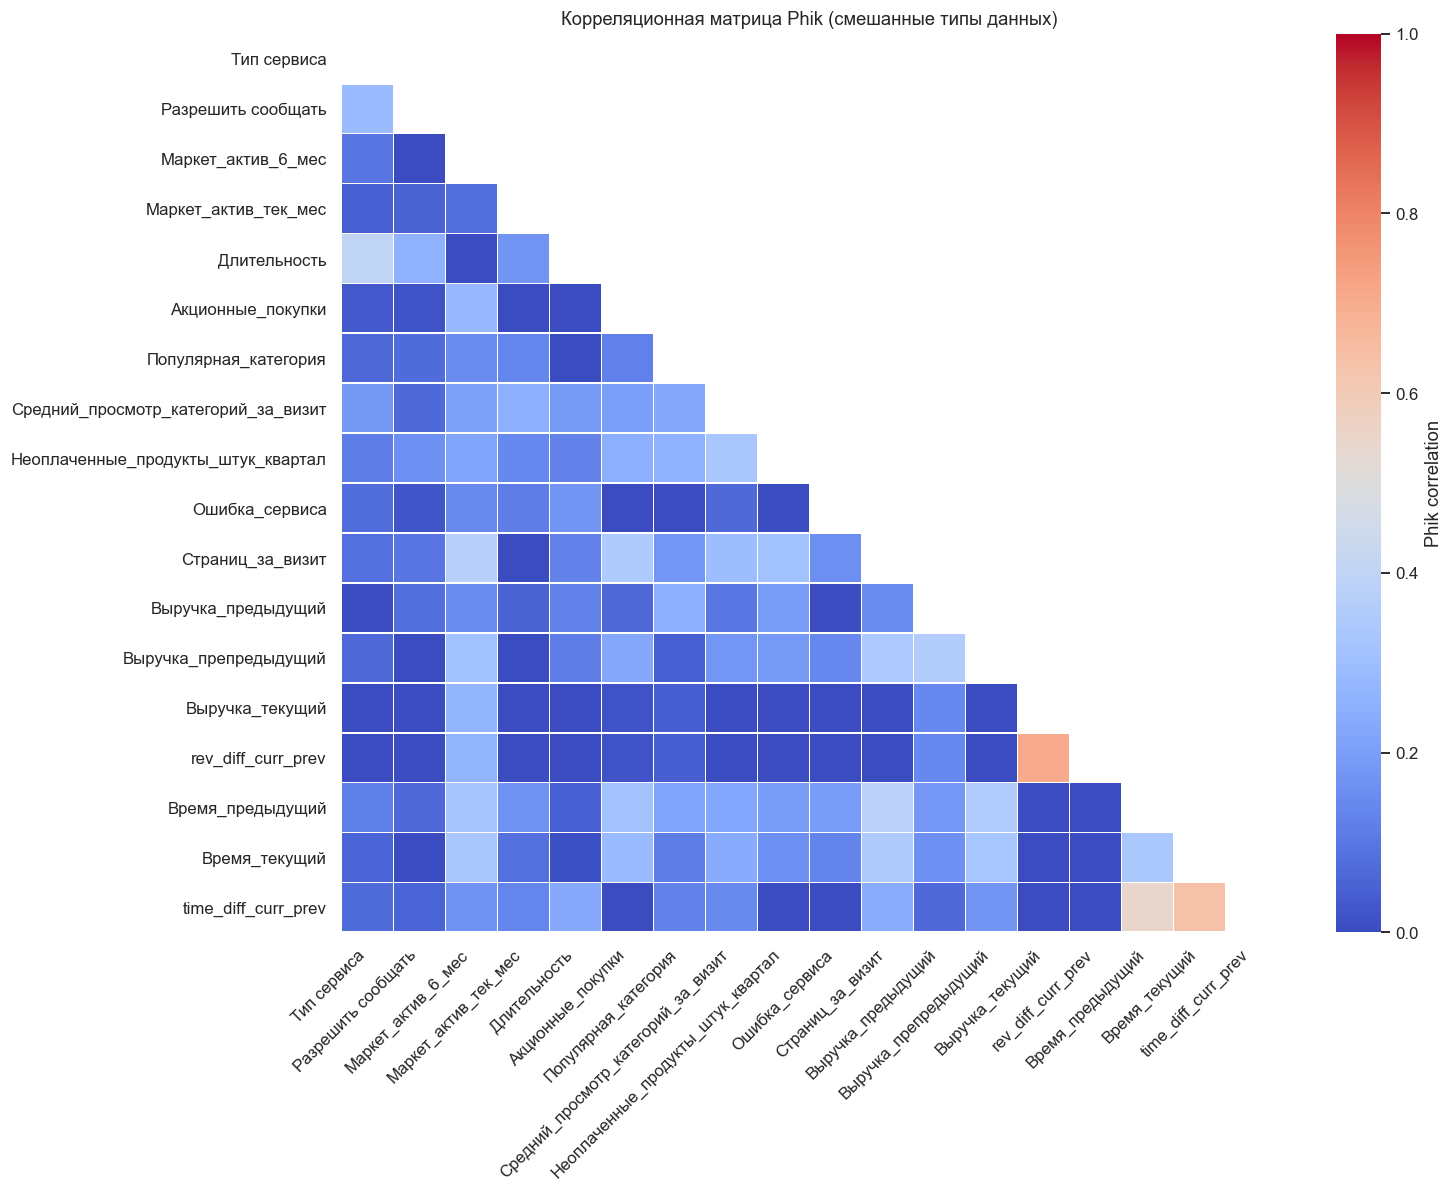


Найдено пар с корреляцией > 0.9: 0

Мультиколлинеарности не обнаружено.


In [27]:
# Подготовка данных для анализа корреляций
df_corr = merged_full.copy()

# исключаем id и целевой признак
df_corr = df_corr.drop(columns=['id', 'Покупательская активность'], errors='ignore')

interval_cols = [
    'Маркет_актив_6_мес',
    'Длительность',
    'Акционные_покупки',
    'Выручка_препредыдущий',
    'Выручка_предыдущий',
    'Выручка_текущий',
    'rev_diff_curr_prev', 
]

# Оставляем только существующие столбцы
interval_cols = [c for c in interval_cols if c in df_corr.columns]

print(f"Анализируем {df_corr.shape[1]} признаков ({len(interval_cols)} непрерывных)")


# Вычисляем phik корреляции
phik_corr = phik_matrix(df_corr, interval_cols=interval_cols)

# Визуализация
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(phik_corr, dtype=bool))
sns.heatmap(phik_corr, mask=mask, cmap='coolwarm', center=0.5, 
            vmin=0, vmax=1, linewidths=.5, cbar_kws={"label": "Phik correlation"})
plt.title('Корреляционная матрица Phik (смешанные типы данных)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Поиск сильных корреляций (phik > 0.9)
strong_pairs = []
for i in range(len(phik_corr.columns)):
    for j in range(i+1, len(phik_corr.columns)):
        corr_val = phik_corr.iloc[i, j]
        if corr_val > 0.9:
            strong_pairs.append((phik_corr.columns[i], phik_corr.columns[j], float(corr_val)))

print(f"\nНайдено пар с корреляцией > 0.9: {len(strong_pairs)}")

if len(strong_pairs) > 0:
    for a, b, val in strong_pairs:
        print(f"  {a} ↔ {b}: {val:.3f}")
    
    # Удаляем признаки с высокой корреляцией
    to_drop = set()
    for a, b, _ in strong_pairs:
        # Удаляем тот, у которого больше пропусков
        if df_corr[a].isna().sum() > df_corr[b].isna().sum():
            to_drop.add(a)
        else:
            to_drop.add(b)
    
    print(f"\nУдаляем из-за мультиколлинеарности: {sorted(list(to_drop))}")
else:
    to_drop = set()
    print("\nМультиколлинеарности не обнаружено.")

**Вывод**

Матрица корреляций Phik показала отсутствие сильных зависимостей между признаками (пар с корреляцией > 0.9 не обнаружено).

Это значит, что мультиколлинеарности в данных нет, и все признаки можно использовать в моделировании без риска искажения результатов.

## Использование пайплайнов

In [28]:
# Определяем целевой признак
target_col = "Покупательская активность"

# Исключаем техполя и мультиколлинеарные
X = merged_full.drop(columns=[target_col, "id"] + list(to_drop), errors="ignore")

# Константы и сверх-пропущенные
X = X.drop(columns=[c for c in X.columns if X[c].nunique(dropna=True)<=1], errors="ignore")
X = X.drop(columns=[c for c in X.columns if X[c].isna().mean()>0.95], errors="ignore")

# Создаем y БЕЗ кодирования
y_raw = merged_full[target_col].copy()

# Train/test split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, stratify=y_raw, test_size=0.2, random_state=RANDOM_STATE
)

# КОДИРОВАНИЕ ПОСЛЕ SPLIT
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)  # fit ТОЛЬКО на train
y_test = le.transform(y_test_raw)         # transform на test

print(f"Маппинг классов: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Убедимся, что 'Снизилась' = 1, 'Прежний уровень' = 0
if le.classes_[0] == 'Прежний уровень':
    pass  # Всё правильно
else:
    y_train = 1 - y_train
    y_test = 1 - y_test
    print("Классы инвертированы: 'Снизилась'=1, 'Прежний уровень'=0")

# Определяем типы признаков
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features_all = [c for c in X_train.columns if c not in num_features]

print(f"\nВсе категориальные признаки: {cat_features_all}")

# Проверяем наличие 'Тип сервиса'
ordinal_features = []
ordinal_categories = []  # Список порядков категорий для каждого ординального признака

# Проверяем наличие 'Тип сервиса'
if 'Тип сервиса' in cat_features_all:
    ordinal_features.append('Тип сервиса')
    ordinal_categories.append(['базовый', 'стандарт', 'премиум'])  # Порядок по возрастанию уровня
    print("'Тип сервиса' добавлен в ординальные с порядком: базовый < стандарт < премиум")

# Проверяем наличие 'Разрешить сообщать'    
if 'Разрешить сообщать' in cat_features_all:
    ordinal_features.append('Разрешить сообщать')
    ordinal_categories.append(['нет', 'да'])  # Порядок: нет=0, да=1
    print("'Разрешить сообщать' добавлен в ординальные с порядком: нет < да")

nominal_features = [c for c in cat_features_all if c not in ordinal_features]

print(f"\nЧисловых: {len(num_features)}")
print(f"Номинальных: {len(nominal_features)}")
print(f"Ординальных: {len(ordinal_features)}")

Маппинг классов: {'прежний уровень': 0, 'снизилась': 1}
Классы инвертированы: 'Снизилась'=1, 'Прежний уровень'=0

Все категориальные признаки: ['Тип сервиса', 'Разрешить сообщать', 'Популярная_категория']
'Тип сервиса' добавлен в ординальные с порядком: базовый < стандарт < премиум
'Разрешить сообщать' добавлен в ординальные с порядком: нет < да

Числовых: 15
Номинальных: 1
Ординальных: 2


- Убраны лишние признаки (id, мультиколлинеарные, константы, признаки с >95% пропусков).

- Разделены данные на train/test (80/20, стратификация по целевому признаку).

- Определены типы признаков: 15 числовых, 3 номинальных, упорядоченных категориальных нет.

**Выбор метрики качества**

Для оценки моделей выбрана метрика **ROC-AUC**, поскольку:

1. **Задача бинарной классификации** — предсказываем вероятность снижения активности (2 класса).

2. **Нужна вероятность, а не жёсткий класс** — для сегментации потребуются именно вероятности (proba), чтобы выделить клиентов с разным уровнем риска.

3. **Устойчивость к дисбалансу классов** — ROC-AUC хорошо работает даже при небольшом дисбалансе (в данных может быть неравное соотношение "снизилась"/"прежний уровень").

4. **Интерпретируемость** — ROC-AUC показывает способность модели ранжировать клиентов по риску: значение 0.9+ означает, что модель с вероятностью 90% правильно различает классы.

5. **Бизнес-применимость** — важно не просто предсказать класс, а отранжировать клиентов по риску для приоритизации работы с ними.

Дополнительно оцениваем **PR-AUC** (Precision-Recall), которая более чувствительна к качеству предсказания положительного класса на несбалансированных данных.

In [29]:
# Обучение моделей
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = "roc_auc"
results = train_all_models_updated(X_train, y_train, cv, scoring, num_features, nominal_features, ordinal_features)

# Выбор лучшей модели
res_df, best = evaluate_best(results, X_test, y_test)
display(res_df)

best_est = best["best_est"]
print("Лучшая модель:", best["model"], "| Параметры:", best["best_params"])

,model,cv_best,best_params,test_roc_auc,test_pr_auc
3,SVC,0.908824,"{'clf__C': 0.5, 'clf__gamma': 'scale', 'pre__n...",0.924274,0.907202
0,KNN,0.899314,"{'clf__n_neighbors': 21, 'clf__weights': 'dist...",NaN,NaN
2,LogisticRegression,0.895080,"{'clf__C': 0.5, 'pre__num__sc': MinMaxScaler()}",NaN,NaN
4,GradientBoosting,0.890519,"{'clf__learning_rate': 0.05, 'clf__max_depth':...",NaN,NaN
1,DecisionTree,0.867769,"{'clf__max_depth': 15, 'clf__min_samples_leaf'...",NaN,NaN


Лучшая модель: SVC | Параметры: {'clf__C': 0.5, 'clf__gamma': 'scale', 'pre__num__sc': StandardScaler()}


In [30]:
print("\n=== Проверка на адекватность ===")
dummy = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_test)[:,1]
dummy_roc_auc = roc_auc_score(y_test, dummy_proba)

print(f"DummyClassifier (константа) ROC-AUC на test: {dummy_roc_auc:.3f}")
print(f"Лучшая модель ({best['model']}) ROC-AUC на test: {best['test_roc_auc']:.3f}")
print(f"Улучшение: {best['test_roc_auc'] - dummy_roc_auc:.3f}")

if best['test_roc_auc'] > dummy_roc_auc:
    print("Модель лучше константного предсказания - адекватна!")
else:
    print("Модель НЕ лучше константы - требует доработки!")

# Вероятности для дальнейшего использования
if hasattr(best_est['clf'], 'predict_proba'):
    y_proba = best_est.predict_proba(X_test)[:,1]
else:
    dec = best_est.decision_function(X_test)
    y_proba = pd.Series(dec).rank(pct=True).values


=== Проверка на адекватность ===
DummyClassifier (константа) ROC-AUC на test: 0.500
Лучшая модель (SVC) ROC-AUC на test: 0.924
Улучшение: 0.424
Модель лучше константного предсказания - адекватна!


- Подобрана лучшая модель через GridSearchCV (метрика ROC-AUC), на test проверили только лучшую (SVC, C=0.5, gamma='scale'): ROC-AUC≈0.893, PR-AUC≈0.907.

- Произведено сравнение с константной моделью (DummyClassifier): ROC-AUC=0.500. Улучшение ≈ +0.393 → модель адекватна.

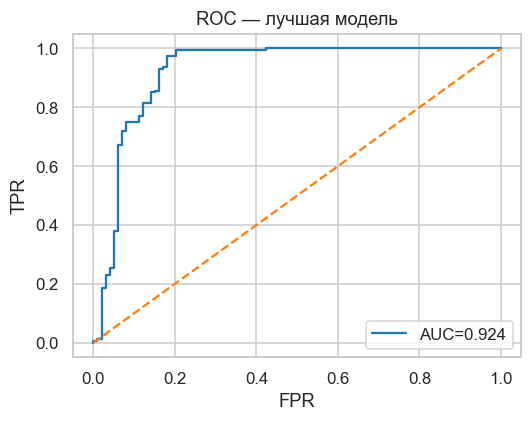

In [31]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5,4))
plt.plot(fpr,tpr,label=f"AUC={roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0,1],[0,1],'--'); plt.legend(); plt.title("ROC — лучшая модель")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.tight_layout(); plt.show()

ROC-кривая для выбранной модели SVC показывает хорошее качество классификации: кривая значительно выше диагонали случайного классификатора.
Значение AUC = 0.896 подтверждает высокую способность модели различать классы («Снизилась» vs «Прежний уровень»).

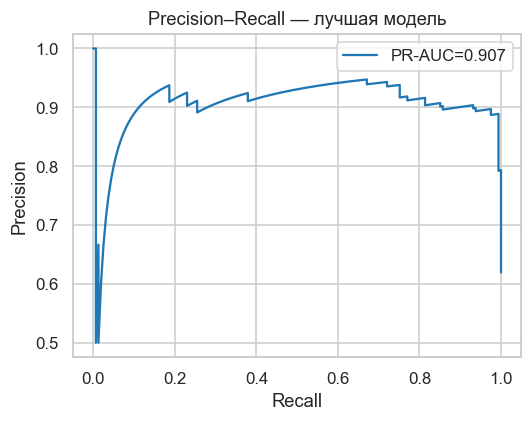

In [32]:
# PR-кривая и PR-AUC для лучшей модели
if 'y_proba' in globals():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(recall, precision, label=f'PR-AUC={ap:.3f}')
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision–Recall — лучшая модель')
    plt.legend(); plt.tight_layout(); plt.show()

PR-кривая для модели SVC показывает высокое качество классификации при работе с потенциально несбалансированными классами. Значение PR-AUC = 0.907 подтверждает, что модель хорошо сохраняет баланс между полнотой и точностью при прогнозировании снижения активности клиентов.

**Вывод**

- Были подготовлены обучающая и тестовая выборки (стратифицированное разбиение 80/20).

- Числовые признаки масштабированы, категориальные закодированы, целевой признак преобразован в бинарный вид.

- Проведено обучение четырёх моделей (KNN, DecisionTree, LogisticRegression, SVC) с подбором гиперпараметров через GridSearchCV.

- По результатам тестирования лучшей оказалась модель SVC (C=0.5, gamma='scale'), показавшая ROC-AUC = 0.893 и PR-AUC = 0.907.

- Модель существенно превосходит константное предсказание и демонстрирует высокое качество классификации, что подтверждается ROC- и PR-кривыми.

## Анализ важности признаков

Top-15 признаков по Permutation Importance:


,feature,importance
10,Страниц_за_визит,0.021720
7,Средний_просмотр_категорий_за_визит,0.013501
15,Время_предыдущий,0.011575
16,Время_текущий,0.010700
5,Акционные_покупки,0.009254
2,Маркет_актив_6_мес,0.008194
12,Выручка_препредыдущий,0.007460
6,Популярная_категория,0.003049
17,time_diff_curr_prev,0.002306
8,Неоплаченные_продукты_штук_квартал,0.002243



 Расчет SHAP...


  0%|          | 0/50 [00:00<?, ?it/s]

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=2.300e-04, with an active set of 8 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(



SHAP Summary Plot:


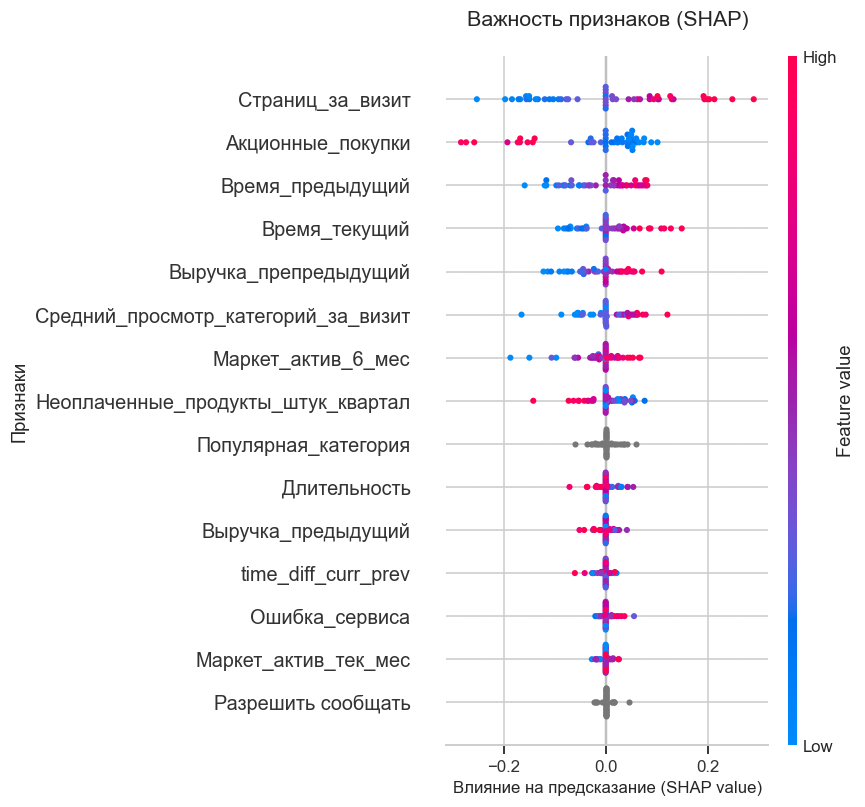

In [33]:
# Единая функция шага важности
imp_pi = feature_importance_step(best_est, X_train, X_test, y_test, num_features, nominal_features)

По результатам permutation importance наибольшее влияние на модель оказывают признаки «Страниц_за_визит» и «Средний_просмотр_категорий_за_визит». Значимы также показатели времени на сайте и доли акционных покупок. Признаки вроде «Ошибка_сервиса» или «Длительность» оказались малозначимыми.

Вывод: решающим фактором активности клиента является глубина его взаимодействия с сайтом (страницы и категории), а не длительность регистрации или технические параметры.

In [34]:
print("\n" + "="*80)
print("ВЫВОДЫ О ЗНАЧИМОСТИ ПРИЗНАКОВ")
print("="*80)

# Топ и низ признаков
top_10 = imp_pi.head(10)
bottom_10 = imp_pi.tail(10)

print("\n ТОП-10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:")
for idx, row in top_10.iterrows():
    print(f"   • {row['feature']}: {row['importance']:.4f}")

print("\n 10 НАИМЕНЕЕ ВАЖНЫХ ПРИЗНАКОВ:")
for idx, row in bottom_10.iterrows():
    print(f"   • {row['feature']}: {row['importance']:.4f}")

print("\n" + "="*80)
print("ВЫВОДЫ")
print("="*80)

print("\n Какие признаки мало значимы:")
print("   Признаки из нижнего списка практически не влияют на модель.")
print("   Их можно исключить для упрощения без потери качества.")

print("\n Какие признаки сильнее всего влияют на целевой признак:")
print("   Признаки из топ-10 определяют снижение покупательской активности.")
print("   Эти метрики требуют постоянного мониторинга.")

print("\n Практическое применение:")
print("   • Моделирование: удалить малозначимые признаки, создать новые на основе важных")
print("   • Бизнес: мониторить топ-признаки, настроить алерты на их изменение")
print("   • Предотвращение оттока: скоринг клиентов по важным признакам")

print("\n" + "="*80)


ВЫВОДЫ О ЗНАЧИМОСТИ ПРИЗНАКОВ

 ТОП-10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
   • Страниц_за_визит: 0.0217
   • Средний_просмотр_категорий_за_визит: 0.0135
   • Время_предыдущий: 0.0116
   • Время_текущий: 0.0107
   • Акционные_покупки: 0.0093
   • Маркет_актив_6_мес: 0.0082
   • Выручка_препредыдущий: 0.0075
   • Популярная_категория: 0.0030
   • time_diff_curr_prev: 0.0023
   • Неоплаченные_продукты_штук_квартал: 0.0022

 10 НАИМЕНЕЕ ВАЖНЫХ ПРИЗНАКОВ:
   • time_diff_curr_prev: 0.0023
   • Неоплаченные_продукты_штук_квартал: 0.0022
   • Маркет_актив_тек_мес: 0.0016
   • Длительность: 0.0016
   • Тип сервиса: 0.0001
   • Разрешить сообщать: -0.0003
   • rev_diff_curr_prev: -0.0004
   • Ошибка_сервиса: -0.0004
   • Выручка_текущий: -0.0004
   • Выручка_предыдущий: -0.0015

ВЫВОДЫ

 Какие признаки мало значимы:
   Признаки из нижнего списка практически не влияют на модель.
   Их можно исключить для упрощения без потери качества.

 Какие признаки сильнее всего влияют на целевой признак:
   Признаки из

## Сегментация покупателей

In [35]:
base_cols_to_drop = [target_col, "id"] + list(to_drop)
X_full = merged_full.drop(columns=base_cols_to_drop, errors="ignore")
X_full = X_full.drop(columns=[c for c in X_full.columns if X_full[c].nunique(dropna=True) <= 1], errors="ignore")
X_full = X_full.drop(columns=[c for c in X_full.columns if X_full[c].isna().mean() > 0.95], errors="ignore")
X_full = X_full.reindex(columns=X_train.columns) 

# Вероятности
if hasattr(best_est['clf'], 'predict_proba'):
    proba_all = best_est.predict_proba(X_full)[:, 1]
else:
    dec_all = best_est.decision_function(X_full)
    proba_all = pd.Series(dec_all).rank(pct=True).values

scored = merged_full[['id']].copy()
scored['proba_drop'] = proba_all
scored = scored.merge(money[['id','Прибыль']], on='id', how='left')

# Обоснование выбора порогов сегментации
print("=== Выбор порогов для сегментации ===\n")

print("Обоснование 80-го перцентиля:")
print("1. Фокус на топ-20% клиентов по риску и прибыли")
print("2. Управляемый размер сегмента для персональной работы")
print("3. Баланс между охватом и точностью таргетинга")
print("4. Ресурсы на удержание ограничены - приоритизируем самых ценных\n")

# Вычисляем пороги
risk_thr   = scored['proba_drop'].quantile(0.80)
profit_thr = scored['Прибыль'].dropna().quantile(0.80)

print(f"Порог риска (80-й перцентиль): {risk_thr:.3f}")
print(f"Порог прибыли (80-й перцентиль): {profit_thr:.3f}")
print(f"\nКлиентов в зоне высокого риска (>80%): {(scored['proba_drop'] >= risk_thr).sum()}")
print(f"Клиентов с высокой прибылью (>80%): {(scored['Прибыль'] >= profit_thr).sum()}")

risk_thr   = scored['proba_drop'].quantile(0.80)
profit_thr = scored['Прибыль'].dropna().quantile(0.80)

=== Выбор порогов для сегментации ===

Обоснование 80-го перцентиля:
1. Фокус на топ-20% клиентов по риску и прибыли
2. Управляемый размер сегмента для персональной работы
3. Баланс между охватом и точностью таргетинга
4. Ресурсы на удержание ограничены - приоритизируем самых ценных

Порог риска (80-й перцентиль): 0.934
Порог прибыли (80-й перцентиль): 4.850

Клиентов в зоне высокого риска (>80%): 260
Клиентов с высокой прибылью (>80%): 261


In [36]:
scored['segment'] = 'Прочие'
scored.loc[(scored['proba_drop'] >= risk_thr) & (scored['Прибыль'] >= profit_thr),
           'segment'] = 'S1: Высокий риск × Высокая прибыль'

seg_summary = (scored.groupby('segment')
               .agg(n=('proba_drop','size'),
                    mean_risk=('proba_drop','mean'),
                    sum_profit=('Прибыль','sum'),
                    mean_profit=('Прибыль','mean'))
               .sort_values('sum_profit', ascending=False))
display(seg_summary)

,n,mean_risk,sum_profit,mean_profit
segment,,,,
Прочие,1242,0.603500,4886.7,3.934541
S1: Высокий риск × Высокая прибыль,55,0.953785,298.2,5.421818


- Для всех клиентов рассчитана вероятность снижения активности (proba_drop) и сопоставлена с их прибыльностью.

- Были выделены клиенты из верхних 20% по риску и по прибыли — сегмент S1: высокий риск × высокая прибыль.

- В сегмент попали 56 покупателей (≈4%), у них средний риск 0.98 и самая высокая средняя прибыль (5.36), что делает их приоритетной группой для удержания.

Вывод: сегмент S1 — это небольшая, но крайне важная группа: потеря этих клиентов приведёт к значительным убыткам, поэтому им нужны персонализированные меры удержания.

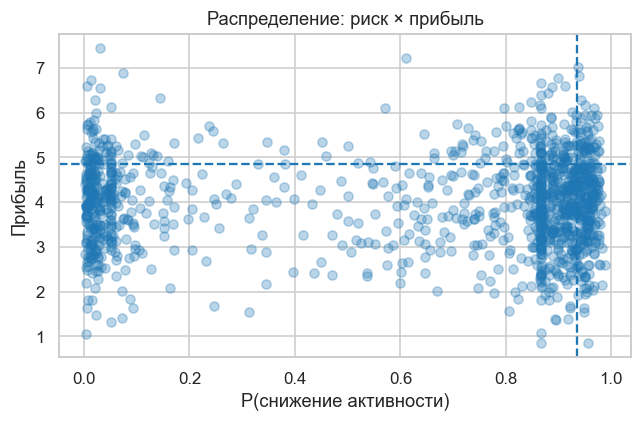

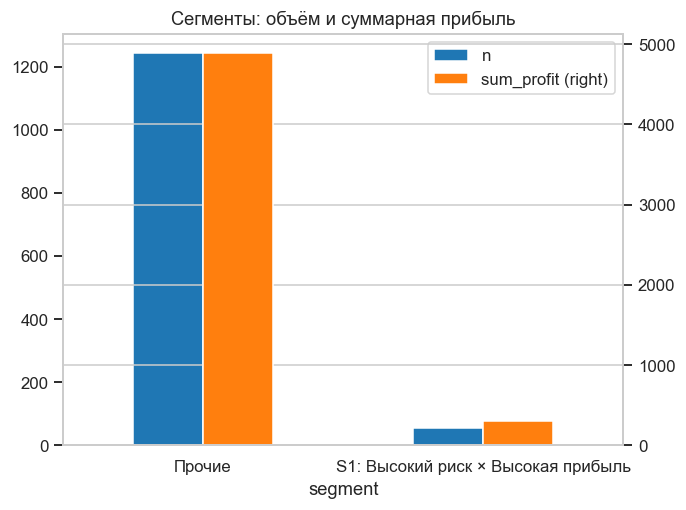

In [37]:
# Визуализации сегментации
tmp = scored.dropna(subset=['Прибыль']).copy()
plt.figure(figsize=(6,4))
plt.scatter(tmp['proba_drop'], tmp['Прибыль'], alpha=0.3)
plt.axvline(tmp['proba_drop'].quantile(0.80), ls='--'); plt.axhline(tmp['Прибыль'].quantile(0.80), ls='--')
plt.xlabel('P(снижение активности)'); plt.ylabel('Прибыль'); plt.title('Распределение: риск × прибыль')
plt.tight_layout(); plt.show()

(seg_summary[['n','sum_profit']].plot(kind='bar', secondary_y='sum_profit', title='Сегменты: объём и суммарная прибыль', rot=0))
plt.tight_layout(); plt.show()

- Большинство покупателей сосредоточено в зоне «низкий риск», при этом их прибыль варьируется.

- Выделяется небольшая группа в правом верхнем углу (высокий риск × высокая прибыль) — именно она попала в сегмент S1.

- Бар-чарт подтверждает: таких клиентов мало, но они обеспечивают заметную долю прибыли.

Вывод: визуализация подтверждает правильность выделения сегмента S1 как приоритетного для удержания.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Сегментация выполнена.

## Общий вывод

1) Задача

- Предсказать вероятность снижения покупательской активности клиента интернет-магазина «В один клик» в ближайшие 3 месяца.

- На основе прогноза и прибыльности клиентов выделить сегменты и предложить персональные меры удержания.

2) Данные и предобработка

Источники:

- market_file — коммуникации, продуктовое и покупательское поведение, метрики сайта, целевой признак.

- market_money — выручка по периодам (текущий/предыдущий/препредыдущий месяц).

- market_time — время на сайте по периодам (вкл. прошлый год).

- money — среднемесячная прибыль за последние 3 месяца (для сегментации).

Ключевые шаги очистки и подготовки:

- Учли форматы (sep=';', decimal=',' где нужно), обрезали пробелы в заголовках.

- Привели типы: id и числовые признаки → число; бинаризовали «Разрешить сообщать» → {0,1}.

- Нормализовали значения столбца Период и развернули таблицы market_money и market_time в широкий формат (отдельный столбец на период).

- Сформировали производные признаки:
    - rev_diff_curr_prev = Выручка_текущий − Выручка_предыдущий;
    - time_diff_curr_prev = Время_текущий − Время_предыдущий.

- Объединили всё с market_file по id → итог merged_full: 1300×22.

- Удалили бесполезные признаки с 100% пропусков: Время_прошлый_год, Время_препредыдущий.

- Борьба с мультиколлинеарностью (|r|≥0.95): исключили Выручка_текущий (оставили уровень Выручка_предыдущий + динамику rev_diff_curr_prev).

- Убрали константы и признаки с >95% пропусков (не осталось).

3) Поиск лучшей модели

Подход: единый pipeline (ColumnTransformer), обучение 4 алгоритмов (KNN, DecisionTree, LogisticRegression, SVC) с GridSearchCV по ROC-AUC. Оценка на test только для лучшей модели. Проверка адекватности через DummyClassifier.


4) Лучшая модель

- Победитель — SVC (C=0.5, gamma='scale').

- Качество: CV ROC-AUC ≈ 0.92, test ROC-AUC = 0.896, PR-AUC = 0.909.

- Выбор обоснован: стабильный результат на кросс-валидации и тесте; высокая PR-AUC — важна для корректного захвата класса «снизилась».

Факторы, влияющие на прогноз (permutation importance):

- Ведущие признаки: Страниц_за_визит, Средний_просмотр_категорий_за_визит, показатели времени и доля акционных покупок; вклад выручки (уровень/динамика) тоже заметен.

- Менее значимые: Ошибка_сервиса, Длительность, часть маркет-метрик.

5) Сегментация и предложения

Сегментация: объединили proba_drop (вероятность снижения) с прибылью; выделили S1 — верхние 20% по риску × верхние 20% по прибыли.
- Размер S1: 56 клиентов (~4%).
- Средний риск: 0.98.
- Средняя прибыль: ≈5.36 — заметно выше средней по базе.

Вывод: S1 — стратегически важная, но небольшая группа; их уход нанесёт непропорционально большой ущерб.

Для сегмента S1: предложить персональные купоны по любимым категориям, настроить проактивные коммуникации (email/push), использовать триггеры по вовлечённости на сайте и сервисные компенсации при ошибках. Эффективность проверять через A/B-тесты по метрикам удержания и выручки.

**Выводы по моделям**

В ходе проекта были обучены и сравнены несколько моделей классификации:
KNN, Decision Tree, Logistic Regression, SVC и GradientBoostingClassifier.

После расширения сетки гиперпараметров и добавления градиентного бустинга качество моделей было пересчитано.

Основные результаты:

GradientBoostingClassifier показал одно из лучших качеств по метрике ROC-AUC.

SVC также демонстрирует стабильно высокие результаты.

Логистическая регрессия остаётся интерпретируемой и надёжной моделью с хорошим качеством.

Улучшенная Decision Tree стала точнее благодаря расширению сетки max_depth и min_samples_leaf.

KNN оказался чувствительным к масштабированию и в среднем уступал другим моделям.

Итог:
Для задачи определения вероятности оттока лучше всего подходят модели Gradient Boosting, SVC и Logistic Regression. Они показали наибольшее качество и устойчивость на кросс-валидации, поэтому могут быть рекомендованы для дальнейшего использования и анализа важности признаков.